# <font color="purple">EDA</font>
## <font color="purple">(exploratory data analysis)</font>

# <font color="1E93AB">Import Libraries</font>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder

In [2]:
#load data
df1= pd.read_excel('OnlineRetail_part1.xlsx')
df2= pd.read_csv("OnlineRetail_part2.csv")
df= pd.concat([df1 ,df2], ignore_index=True)
df


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,555200,71459,HANGING JAM JAR T-LIGHT HOLDER,24.0,2011-06-01 12:05:00,0.85,17315.0,United Kingdom
1,554974,21128,GOLD FISHING GNOME,4.0,2011-05-27 17:14:00,6.95,14031.0,United Kingdom
2,550972,21086,SET/6 RED SPOTTY PAPER CUPS,4.0,2011-04-21 17:05:00,0.65,14031.0,United Kingdom
3,576652,22812,PACK 3 BOXES CHRISTMAS PANETTONE,3.0,2011-11-16 10:39:00,1.95,17198.0,United Kingdom
4,546157,22180,RETROSPOT LAMP,2.0,2011-03-10 08:40:00,9.95,13502.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22367,CHILDRENS APRON SPACEBOY DESIGN,8.0,2011-12-09 12:50:00,1.95,12680.0,France
541905,581587,22629,SPACEBOY LUNCH BOX,12.0,2011-12-09 12:50:00,1.95,12680.0,France
541906,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12.0,2011-12-09 12:50:00,0.85,12680.0,France
541907,581587,22899,CHILDREN'S APRON DOLLY GIRL,6.0,2011-12-09 12:50:00,2.10,12680.0,France


# <font color="1E93AB">Explore Data</font>

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     515060 non-null  float64
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    504135 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(3), object(5)
memory usage: 33.1+ MB


In [4]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,515060.000000,504135.000000,406829.000000
mean,56.580255,14.846426,15287.690570
std,390.976543,135.781098,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.100000,15152.000000
75%,12.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [5]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity        26849
InvoiceDate         0
UnitPrice       37774
CustomerID     135080
Country             0
dtype: int64

In [6]:
#duplication
df.duplicated().sum()

np.int64(1953)

In [7]:
df= df.drop_duplicates()

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['Country'].value_counts()

Country
United Kingdom          478593
                         16383
Germany                   9172
France                    8310
EIRE                      7968
Spain                     2454
Netherlands               2309
Belgium                   2006
Switzerland               1925
Portugal                  1470
Australia                 1218
Norway                    1045
Italy                      780
Channel Islands            729
Finland                    675
Cyprus                     601
Sweden                     445
Unspecified                428
Austria                    387
Denmark                    373
Japan                      349
Poland                     332
Israel                     290
USA                        282
Hong Kong                  279
Singapore                  218
Iceland                    181
Canada                     145
Greece                     140
Malta                      120
United Arab Emirates        66
European Community          59


In [10]:
df['Description'].value_counts()

Description
WHITE HANGING HEART T-LIGHT HOLDER     2365
REGENCY CAKESTAND 3 TIER               2197
JUMBO BAG RED RETROSPOT                2159
PARTY BUNTING                          1724
LUNCH BAG RED RETROSPOT                1629
                                       ... 
FOUND                                     1
incorrectly put back into stock           1
historic computer difference?....se       1
WET/MOULDY                                1
ANT SILVER TURQUOISE BOUDICCA RING        1
Name: count, Length: 4223, dtype: int64

# <font color="1E93AB">Clean Data</font>

## -Column InvoiceNo

In [11]:
#df without cancellation
df_withoutc= df[~df['InvoiceNo'].str.contains('C' ,na=False)]
df_withoutc

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,555200,71459,HANGING JAM JAR T-LIGHT HOLDER,24.0,2011-06-01 12:05:00,0.85,17315.0,United Kingdom
1,554974,21128,GOLD FISHING GNOME,4.0,2011-05-27 17:14:00,6.95,14031.0,United Kingdom
2,550972,21086,SET/6 RED SPOTTY PAPER CUPS,4.0,2011-04-21 17:05:00,0.65,14031.0,United Kingdom
3,576652,22812,PACK 3 BOXES CHRISTMAS PANETTONE,3.0,2011-11-16 10:39:00,1.95,17198.0,United Kingdom
4,546157,22180,RETROSPOT LAMP,2.0,2011-03-10 08:40:00,9.95,13502.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22367,CHILDRENS APRON SPACEBOY DESIGN,8.0,2011-12-09 12:50:00,1.95,12680.0,France
541905,581587,22629,SPACEBOY LUNCH BOX,12.0,2011-12-09 12:50:00,1.95,12680.0,France
541906,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12.0,2011-12-09 12:50:00,0.85,12680.0,France
541907,581587,22899,CHILDREN'S APRON DOLLY GIRL,6.0,2011-12-09 12:50:00,2.10,12680.0,France


## -Column StockCode

In [12]:
#short values
short_codes= df[df['StockCode'].str.len()<5]['StockCode'].unique()
short_codes

array(['M', 'POST', 'DOT', 'C2', 'D', 'S', 'PADS', 'CRUK', 'B', 'm'],
      dtype=object)

In [13]:
invalid_codes= ['M', 'POST', 'DOT', 'C2', 'D', 'S', 'PADS', 'CRUK', 'B', 'm']
#drop invalid values
df= df[~df['StockCode'].isin(invalid_codes)]

In [14]:
short_codes= df[df['StockCode'].str.len()<5]['StockCode'].unique()
short_codes

array([], dtype=object)

In [15]:
df['StockCode']= df['StockCode'].str.strip()

In [16]:
short_codes= df[df['StockCode'].str.len()<5]['StockCode'].unique()
short_codes

array([], dtype=object)

In [17]:
df['StockCode'].isna().sum()

np.int64(242729)

In [18]:
df['StockCode']= df['StockCode'] .replace(np.nan,'unknown')

In [19]:
df['StockCode'].isna().sum()

np.int64(0)

## -Column Description

In [20]:
df['Description']= df['Description'].str.upper().str.strip()
noise_list= ['DOTCOMSTOCK','AMAZON STOCK','DAMAGED','WRONG','LOST','ADJUST','CHECK','DOTCOM','POSTAGE','DAMAGE','DISCARDED']
for word in noise_list:
    df= df[~df['Description'].str.contains(word,na=False)]
#remove missing information 
df.dropna(subset=['Description'] ,inplace=True)

In [21]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,555200,unknown,HANGING JAM JAR T-LIGHT HOLDER,24.0,2011-06-01 12:05:00,0.85,17315.0,United Kingdom
1,554974,unknown,GOLD FISHING GNOME,4.0,2011-05-27 17:14:00,6.95,14031.0,United Kingdom
2,550972,unknown,SET/6 RED SPOTTY PAPER CUPS,4.0,2011-04-21 17:05:00,0.65,14031.0,United Kingdom
3,576652,unknown,PACK 3 BOXES CHRISTMAS PANETTONE,3.0,2011-11-16 10:39:00,1.95,17198.0,United Kingdom
4,546157,unknown,RETROSPOT LAMP,2.0,2011-03-10 08:40:00,9.95,13502.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22367,CHILDRENS APRON SPACEBOY DESIGN,8.0,2011-12-09 12:50:00,1.95,12680.0,France
541905,581587,22629,SPACEBOY LUNCH BOX,12.0,2011-12-09 12:50:00,1.95,12680.0,France
541906,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12.0,2011-12-09 12:50:00,0.85,12680.0,France
541907,581587,22899,CHILDREN'S APRON DOLLY GIRL,6.0,2011-12-09 12:50:00,2.10,12680.0,France


## -Column Quantity

In [22]:
df= df[df['Quantity']>0]
df['IsCancelled']= df['InvoiceNo'].str.startswith('C', na=False)
df.dropna(subset=['Quantity','UnitPrice'], inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_20612\1303850679.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['IsCancelled']= df['InvoiceNo'].str.startswith('C', na=False)
C:\Users\User\AppData\Local\Temp\ipykernel_20612\1303850679.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(subset=['Quantity','UnitPrice'], inplace=True)


In [23]:
df['Quantity'].value_counts()

Quantity
1.0        125415
2.0         70354
12.0        52717
6.0         35142
4.0         33097
            ...  
1120.0          1
77.0            1
177.0           1
388.0           1
80995.0         1
Name: count, Length: 360, dtype: int64

In [24]:
#outliers
Q1= df['Quantity']. quantile(0.25)
Q3= df['Quantity']. quantile(0.75)
IQR= Q3 -Q1

lower_bound= Q1 -1.5*IQR
upper_bound= Q3 +1.5*IQR
median_value= df['Quantity'].median()
median_value
df.loc[(df['Quantity']< lower_bound) | (df['Quantity']> upper_bound) , 'Quantity'] =median_value

In [25]:
df['Quantity'].value_counts()

Quantity
1.0     125415
2.0      70354
4.0      66320
12.0     52717
6.0      35142
3.0      31948
24.0     20791
10.0     19287
8.0      11284
5.0      10104
25.0      4408
20.0      4302
16.0      3691
7.0       2498
9.0       1765
18.0      1538
11.0       798
15.0       676
13.0       516
14.0       481
17.0       233
19.0       178
28.0       150
22.0       144
21.0       144
23.0        91
27.0        91
26.0        81
Name: count, dtype: int64

In [26]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled
0,555200,unknown,HANGING JAM JAR T-LIGHT HOLDER,24.0,2011-06-01 12:05:00,0.85,17315.0,United Kingdom,False
1,554974,unknown,GOLD FISHING GNOME,4.0,2011-05-27 17:14:00,6.95,14031.0,United Kingdom,False
2,550972,unknown,SET/6 RED SPOTTY PAPER CUPS,4.0,2011-04-21 17:05:00,0.65,14031.0,United Kingdom,False
3,576652,unknown,PACK 3 BOXES CHRISTMAS PANETTONE,3.0,2011-11-16 10:39:00,1.95,17198.0,United Kingdom,False
4,546157,unknown,RETROSPOT LAMP,2.0,2011-03-10 08:40:00,9.95,13502.0,United Kingdom,False
...,...,...,...,...,...,...,...,...,...
541904,581587,22367,CHILDRENS APRON SPACEBOY DESIGN,8.0,2011-12-09 12:50:00,1.95,12680.0,France,False
541905,581587,22629,SPACEBOY LUNCH BOX,12.0,2011-12-09 12:50:00,1.95,12680.0,France,False
541906,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12.0,2011-12-09 12:50:00,0.85,12680.0,France,False
541907,581587,22899,CHILDREN'S APRON DOLLY GIRL,6.0,2011-12-09 12:50:00,2.10,12680.0,France,False


In [27]:
errors=[]
for i in df['Quantity']:
    try:
        float(i)
    except:
        errors.append(i)

print(set(errors))

set()


In [28]:
df['Quantity'].max()

28.0

## -Column InvoiceDate

In [29]:
df['InvoiceDate']= pd.to_datetime(df['InvoiceDate'])
print(df['InvoiceDate'].min())
print(df['InvoiceDate'].max())

2010-12-01 08:26:00
2011-12-09 12:50:00


C:\Users\User\AppData\Local\Temp\ipykernel_20612\1959250554.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['InvoiceDate']= pd.to_datetime(df['InvoiceDate'])


In [30]:
df['InvoiceDate']= pd.to_datetime(df['InvoiceDate'])
df['Year']= df['InvoiceDate'].dt.year
df['Month']= df['InvoiceDate'].dt.month
df['Day']= df['InvoiceDate'].dt.day
df['Hour']= df['InvoiceDate'].dt.hour
df['DayOfWeek']= df['InvoiceDate'].dt.dayofweek

C:\Users\User\AppData\Local\Temp\ipykernel_20612\1901423477.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['InvoiceDate']= pd.to_datetime(df['InvoiceDate'])
C:\Users\User\AppData\Local\Temp\ipykernel_20612\1901423477.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year']= df['InvoiceDate'].dt.year
C:\Users\User\AppData\Local\Temp\ipykernel_20612\1901423477.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer]

In [31]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled,Year,Month,Day,Hour,DayOfWeek
0,555200,unknown,HANGING JAM JAR T-LIGHT HOLDER,24.0,2011-06-01 12:05:00,0.85,17315.0,United Kingdom,False,2011,6,1,12,2
1,554974,unknown,GOLD FISHING GNOME,4.0,2011-05-27 17:14:00,6.95,14031.0,United Kingdom,False,2011,5,27,17,4
2,550972,unknown,SET/6 RED SPOTTY PAPER CUPS,4.0,2011-04-21 17:05:00,0.65,14031.0,United Kingdom,False,2011,4,21,17,3
3,576652,unknown,PACK 3 BOXES CHRISTMAS PANETTONE,3.0,2011-11-16 10:39:00,1.95,17198.0,United Kingdom,False,2011,11,16,10,2
4,546157,unknown,RETROSPOT LAMP,2.0,2011-03-10 08:40:00,9.95,13502.0,United Kingdom,False,2011,3,10,8,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22367,CHILDRENS APRON SPACEBOY DESIGN,8.0,2011-12-09 12:50:00,1.95,12680.0,France,False,2011,12,9,12,4
541905,581587,22629,SPACEBOY LUNCH BOX,12.0,2011-12-09 12:50:00,1.95,12680.0,France,False,2011,12,9,12,4
541906,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12.0,2011-12-09 12:50:00,0.85,12680.0,France,False,2011,12,9,12,4
541907,581587,22899,CHILDREN'S APRON DOLLY GIRL,6.0,2011-12-09 12:50:00,2.10,12680.0,France,False,2011,12,9,12,4


## -Column UnitPrice

In [32]:
df['UnitPrice'].value_counts()

UnitPrice
1.25     43222
1.65     32609
0.85     24401
2.95     23667
0.42     21087
         ...  
10.39        1
0.52         1
7.84         1
1.86         1
11.25        1
Name: count, Length: 490, dtype: int64

In [33]:
df['UnitPrice'].isna().sum()

np.int64(0)

In [34]:
print(df[df['UnitPrice']<=0].shape[0])

433


In [35]:
df['TotalAmount']= df['Quantity'] *df['UnitPrice']
df.loc[df['UnitPrice'] <=0,'UnitPrice']= np.nan
df.loc[df['UnitPrice']>500 ,'UnitPrice']= np.nan

C:\Users\User\AppData\Local\Temp\ipykernel_20612\2732256393.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['TotalAmount']= df['Quantity'] *df['UnitPrice']


In [36]:
df['UnitPrice']= df['UnitPrice'].fillna(df.groupby('StockCode')['UnitPrice'].transform('median'))
df['unitPrice']= df['UnitPrice'].fillna(df['UnitPrice'].median())

C:\Users\User\AppData\Local\Temp\ipykernel_20612\821569873.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['UnitPrice']= df['UnitPrice'].fillna(df.groupby('StockCode')['UnitPrice'].transform('median'))
C:\Users\User\AppData\Local\Temp\ipykernel_20612\821569873.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['unitPrice']= df['UnitPrice'].fillna(df['UnitPrice'].median())


In [37]:
#outliers
Q1= df['UnitPrice']. quantile(0.25)
Q3= df['UnitPrice']. quantile(0.75)
IQR= Q3 -Q1

lower_bound= Q1 -1.5*IQR
upper_bound= Q3 +1.5*IQR
median_value= df['UnitPrice'].median()
median_value
df.loc[(df['UnitPrice']< lower_bound) | (df['UnitPrice']> upper_bound) ,'UnitPrice'] =median_value

In [38]:
df.loc[df['UnitPrice'] <=0,'UnitPrice']

Series([], Name: UnitPrice, dtype: float64)

In [39]:
df['UnitPrice'].max()

8.33

In [40]:
upper_bound

np.float64(8.45)

## -CustomerID Column

In [41]:
df['CustomerID']= df['CustomerID'] .fillna(0).astype(int)

C:\Users\User\AppData\Local\Temp\ipykernel_20612\723911783.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['CustomerID']= df['CustomerID'] .fillna(0).astype(int)


In [42]:
df['CustomerID']= df['CustomerID'] .replace(0,'unknown')

C:\Users\User\AppData\Local\Temp\ipykernel_20612\3282189258.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['CustomerID']= df['CustomerID'] .replace(0,'unknown')


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 465147 entries, 0 to 541908
Data columns (total 16 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    465147 non-null  object        
 1   StockCode    465147 non-null  object        
 2   Description  465147 non-null  object        
 3   Quantity     465147 non-null  float64       
 4   InvoiceDate  465147 non-null  datetime64[ns]
 5   UnitPrice    465143 non-null  float64       
 6   CustomerID   465147 non-null  object        
 7   Country      465147 non-null  object        
 8   IsCancelled  465147 non-null  bool          
 9   Year         465147 non-null  int32         
 10  Month        465147 non-null  int32         
 11  Day          465147 non-null  int32         
 12  Hour         465147 non-null  int32         
 13  DayOfWeek    465147 non-null  int32         
 14  TotalAmount  465147 non-null  float64       
 15  unitPrice    465147 non-null  float64  

## -Country Column

In [44]:
df['Country'].unique()

array(['United Kingdom', 'Australia', ' ', 'Norway', 'Finland', 'Germany',
       'Bahrain', 'EIRE', 'Spain', 'Canada', 'France', 'RSA',
       'Netherlands', 'Italy', 'Austria', 'Channel Islands',
       'Unspecified', 'Sweden', 'Belgium', 'Cyprus', 'Poland', 'USA',
       'Switzerland', 'Japan', 'Denmark', 'Hong Kong', 'Portugal',
       'Iceland', 'Singapore', 'Israel', 'United Arab Emirates', 'Greece',
       'European Community', 'Malta', 'Saudi Arabia', 'Lebanon',
       'Lithuania', 'Brazil', 'Czech Republic'], dtype=object)

In [45]:
irrelevant_countries= [' ','Unspecified','European Community']
df['Country'].value_counts()

Country
United Kingdom          413488
                         14138
Germany                   7408
France                    6976
EIRE                      6666
Spain                     2095
Netherlands               2000
Belgium                   1653
Switzerland               1640
Portugal                  1234
Australia                 1038
Norway                     912
Italy                      634
Channel Islands            631
Finland                    552
Cyprus                     521
Unspecified                381
Sweden                     362
Austria                    336
Denmark                    318
Poland                     274
Japan                      269
Israel                     254
Hong Kong                  238
Singapore                  185
USA                        160
Iceland                    159
Greece                     121
Canada                     121
Malta                       93
European Community          53
United Arab Emirates        53


In [46]:
df['Country']= df['Country'].replace(irrelevant_countries, 'United Kingdom')

C:\Users\User\AppData\Local\Temp\ipykernel_20612\544264176.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Country']= df['Country'].replace(irrelevant_countries, 'United Kingdom')


In [47]:
df['Country'].unique()

array(['United Kingdom', 'Australia', 'Norway', 'Finland', 'Germany',
       'Bahrain', 'EIRE', 'Spain', 'Canada', 'France', 'RSA',
       'Netherlands', 'Italy', 'Austria', 'Channel Islands', 'Sweden',
       'Belgium', 'Cyprus', 'Poland', 'USA', 'Switzerland', 'Japan',
       'Denmark', 'Hong Kong', 'Portugal', 'Iceland', 'Singapore',
       'Israel', 'United Arab Emirates', 'Greece', 'Malta',
       'Saudi Arabia', 'Lebanon', 'Lithuania', 'Brazil', 'Czech Republic'],
      dtype=object)

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 465147 entries, 0 to 541908
Data columns (total 16 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    465147 non-null  object        
 1   StockCode    465147 non-null  object        
 2   Description  465147 non-null  object        
 3   Quantity     465147 non-null  float64       
 4   InvoiceDate  465147 non-null  datetime64[ns]
 5   UnitPrice    465143 non-null  float64       
 6   CustomerID   465147 non-null  object        
 7   Country      465147 non-null  object        
 8   IsCancelled  465147 non-null  bool          
 9   Year         465147 non-null  int32         
 10  Month        465147 non-null  int32         
 11  Day          465147 non-null  int32         
 12  Hour         465147 non-null  int32         
 13  DayOfWeek    465147 non-null  int32         
 14  TotalAmount  465147 non-null  float64       
 15  unitPrice    465147 non-null  float64  

# <font color="320A6B">Descriptive Analysis</font>

### <font color="0F828C">- average price</font>
### <font color="0F828C">- minimum price</font>
### <font color="0F828C">- maximum price</font>

In [49]:
price_stats= round(df['UnitPrice'].describe()[['mean','min','max']],3)
print('Unit price statistics:')
print(price_stats)
print('-' *30)

Unit price statistics:
mean    2.500
min     0.001
max     8.330
Name: UnitPrice, dtype: float64
------------------------------


### <font color="0F828C">- the highest total sale of a factor</font>

In [50]:
max_quantity_row= df.loc[df['Quantity'].idxmax()]
product_name= max_quantity_row['Description']
max_val= max_quantity_row['Quantity']
print(f'the highest number of sales\nproduct:{product_name}\nnumber:{max_val}') 

the highest number of sales
product:PAPER CHAIN KIT 50'S CHRISTMAS
number:28.0


### <font color="0F828C">- transactions per country</font>

In [51]:
# number of transactions per country
country_transactions = df.groupby('Country')['InvoiceNo'].nunique()

# print the result
for country, num in country_transactions.items():
    print(f'{country} : {num} transactions')

Australia : 101 transactions
Austria : 33 transactions
Bahrain : 5 transactions
Belgium : 190 transactions
Brazil : 2 transactions
Canada : 9 transactions
Channel Islands : 48 transactions
Cyprus : 26 transactions
Czech Republic : 4 transactions
Denmark : 35 transactions
EIRE : 537 transactions
Finland : 74 transactions
France : 735 transactions
Germany : 850 transactions
Greece : 10 transactions
Hong Kong : 14 transactions
Iceland : 14 transactions
Israel : 15 transactions
Italy : 68 transactions
Japan : 32 transactions
Lebanon : 2 transactions
Lithuania : 6 transactions
Malta : 10 transactions
Netherlands : 168 transactions
Norway : 64 transactions
Poland : 36 transactions
Portugal : 98 transactions
RSA : 2 transactions
Saudi Arabia : 2 transactions
Singapore : 8 transactions
Spain : 168 transactions
Sweden : 59 transactions
Switzerland : 97 transactions
USA : 11 transactions
United Arab Emirates : 4 transactions
United Kingdom : 34525 transactions


### <font color="0F828C">- distribution of transactions per country</font>

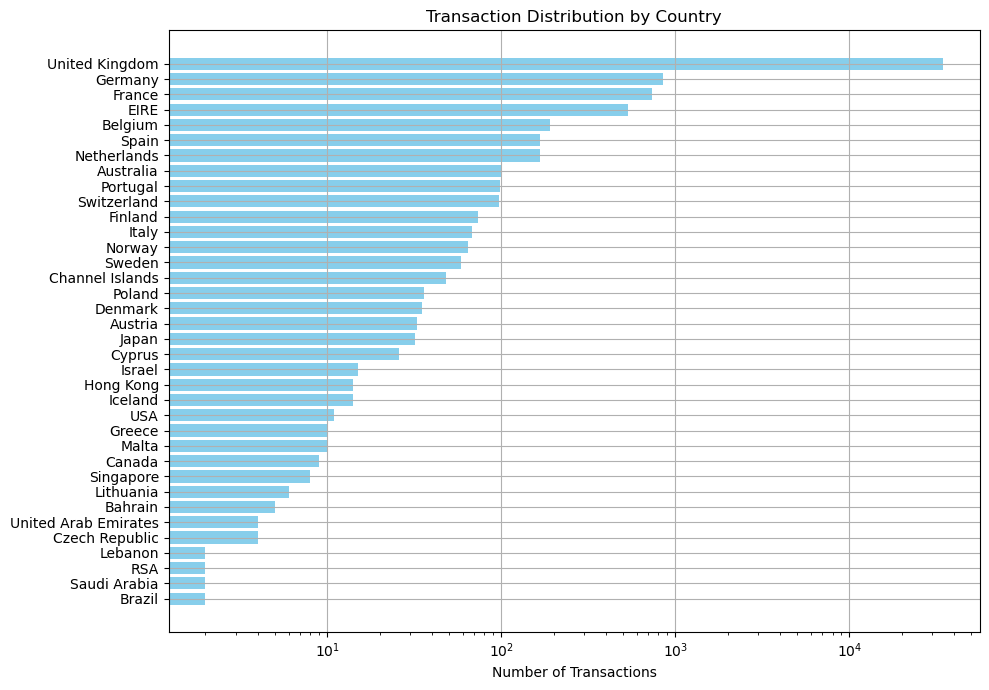

In [52]:
country_transactions = df.groupby('Country')['InvoiceNo'].nunique().sort_values(ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(country_transactions.index, country_transactions.values, color='skyblue')
plt.xscale('log')
plt.xlabel('Number of Transactions')
plt.title('Transaction Distribution by Country')
plt.tight_layout()
plt.grid()
plt.show()

# <font color="696FC7">Diagnostic Analysis</font>

### <font color="4FB7B3">- 1)Why some customers make more purchases</font>

In [53]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'IsCancelled', 'Year', 'Month',
       'Day', 'Hour', 'DayOfWeek', 'TotalAmount', 'unitPrice'],
      dtype='object')

In [54]:
#customers statistics
plt.style.use('seaborn-v0_8')
customer_stats= df.groupby('CustomerID').agg({
    'InvoiceNo': 'count',
    'Quantity': 'sum',
    'UnitPrice': 'mean'
}).rename(columns={'InvoiceNo':'transaction_count' ,'Quantity':'total_quantity'})
customer_stats=customer_stats.reset_index()
customer_stats= customer_stats.sort_values('transaction_count',ascending=False)
customer_stats= customer_stats.set_index('CustomerID')
print('10 customers with the most purchases:')
print(customer_stats.head(10))

10 customers with the most purchases:
            transaction_count  total_quantity  UnitPrice
CustomerID                                              
unknown                116404        298819.0   3.080773
17841                    6834         18210.0   2.148488
14911                    4933         46485.0   2.481027
14096                    4511         13350.0   3.092979
12748                    4003         14229.0   2.048356
14606                    2379          4789.0   2.249243
15311                    2098          8695.0   2.318875
14646                    1819         10425.0   1.833557
13089                    1604         18897.0   2.279464
13263                    1496          3880.0   2.066818


### analytic charts

#### 15 best customers

In [55]:
#outliers
Q1= customer_stats['transaction_count']. quantile(0.25)
Q3= customer_stats['transaction_count']. quantile(0.75)
IQR= Q3 -Q1

lower_bound= Q1 -1.5*IQR
upper_bound= Q3 +1.5*IQR
normal_customers= customer_stats[(customer_stats['transaction_count']>=lower_bound) & (customer_stats['transaction_count']<=upper_bound)]

In [56]:
customer_stats_filtered=customer_stats[customer_stats.index !='unknown']
customer_stats_filtered= customer_stats_filtered.sort_values('transaction_count',ascending=False)

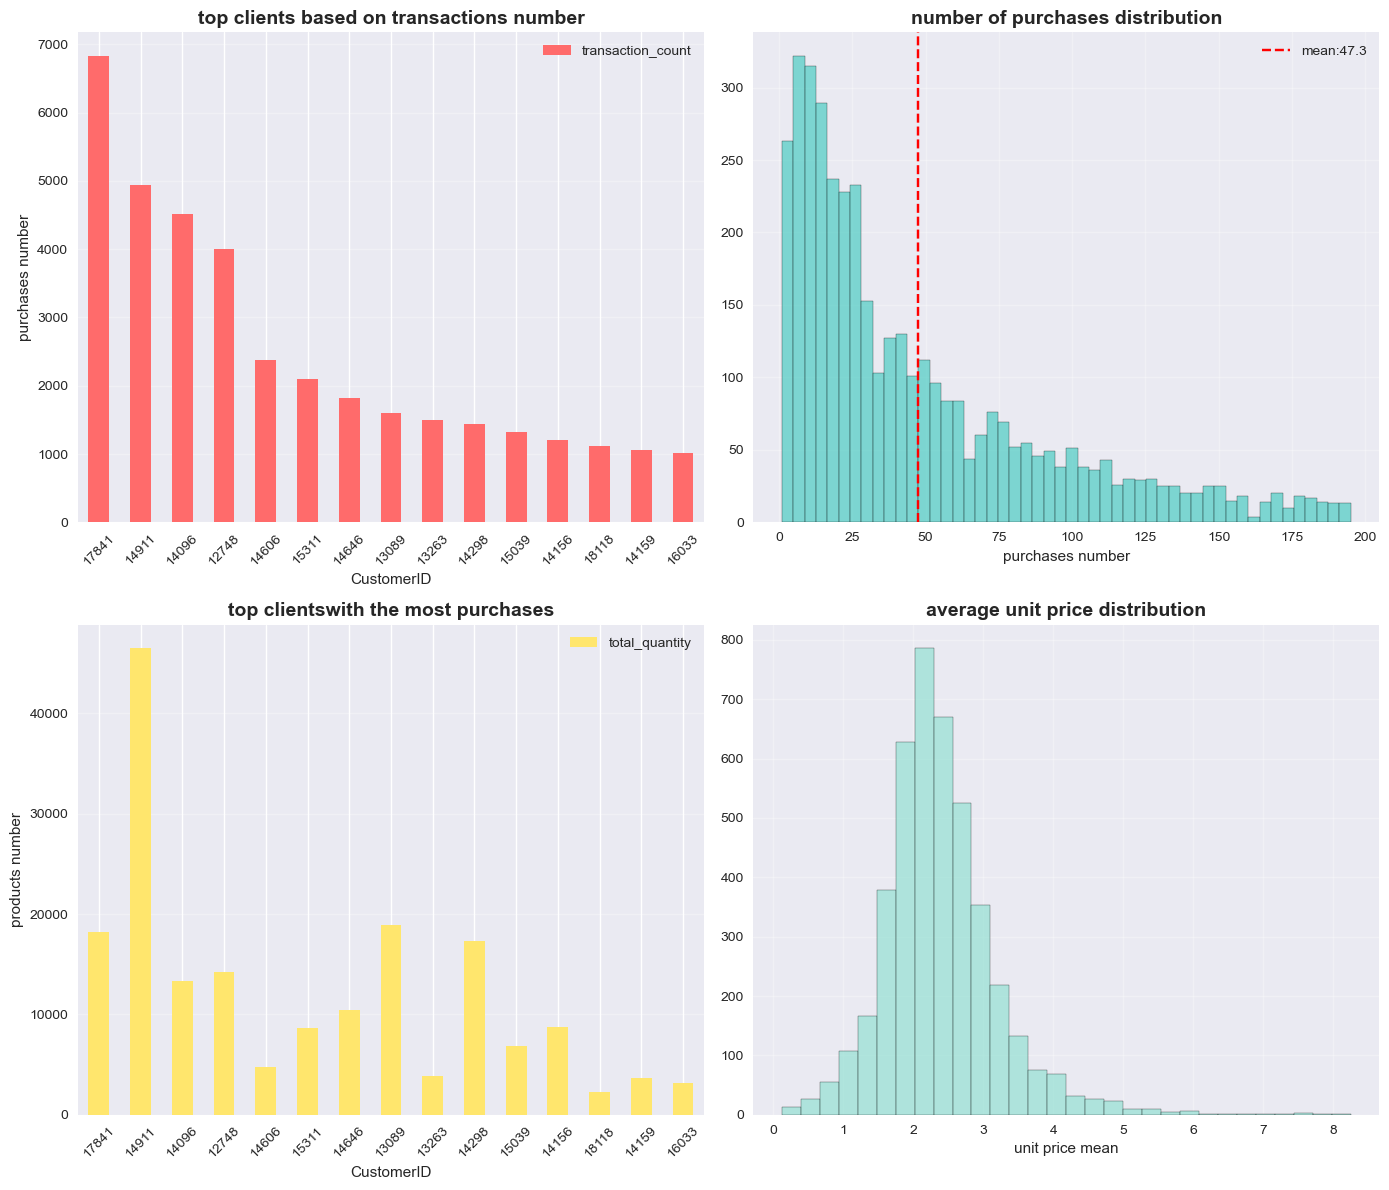

In [57]:
fig, axes = plt.subplots(2,2,figsize=(14,12))
customer_stats_filtered.head(15).plot(kind='bar' ,y='transaction_count',
ax=axes[0,0],color='#FF6B6B')
axes[0,0].set_title('top clients based on transactions number',fontsize=14,fontweight='bold')
axes[0,0].set_ylabel('purchases number')
axes[0,0].tick_params(axis='x',rotation=45)
axes[0,0].grid(axis='y', alpha=0.3)


#distribution
normal_customers['transaction_count'].hist(bins=50, color='#4ECDC4',
edgecolor='black',ax=axes[0,1], alpha=0.7)
axes[0,1].axvline(normal_customers['transaction_count'].mean(),color='red',
linestyle='--',label=f'mean:{normal_customers['transaction_count'].mean():.1f}')
axes[0,1].set_title('number of purchases distribution', fontsize=14,fontweight='bold')
axes[0,1].set_xlabel('purchases number')
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)


customer_stats_filtered.head(15).plot(kind='bar' ,y='total_quantity',
ax=axes[1,0],color='#FFE66D')
axes[1,0].set_title('top clientswith the most purchases',fontsize=14,fontweight='bold')
axes[1,0].set_ylabel('products number')
axes[1,0].tick_params(axis='x',rotation=45)
axes[1,0].grid(axis='y', alpha=0.3)


customer_stats_filtered['UnitPrice'].hist(bins=30, color='#95E1D3',
edgecolor='black',ax=axes[1,1], alpha=0.7)
axes[1,1].set_title('average unit price distribution', fontsize=14,fontweight='bold')
axes[1,1].set_xlabel('unit price mean')
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [58]:
customer_stats['customer_type']= pd.cut(
customer_stats['transaction_count'],
bins=[0,5,20,100,float('inf')],
labels=['low value','regular','active','loyal'])
print('customers categories:')
print(customer_stats['customer_type'].value_counts())

customers categories:
customer_type
active       1980
regular      1086
loyal         925
low value     340
Name: count, dtype: int64


### <font color="4FB7B3">- 2)Do returns occure for specific products?</font>

In [59]:
dataf= df[df['StockCode']!='unknown']

In [60]:
returns= df[df['IsCancelled']==True]

In [61]:
print(f'number of return factors {len(returns)}')
print(f'returns percent of total sales {len(returns)/len(df)*100:.2f}')

number of return factors 172
returns percent of total sales 0.04


In [62]:
top_10_returns= returns.groupby('StockCode')['InvoiceNo'].count().sort_values(ascending=False).head(10)
print('\ntop 10 products:')
print(top_10_returns)


top 10 products:
StockCode
unknown    81
22156       2
22086       2
82483       2
22423       2
21326       2
82486       2
21209       1
20914       1
21272       1
Name: InvoiceNo, dtype: int64


In [63]:
product_sales= df.groupby('StockCode')['InvoiceNo'].count()
product_returns= returns.groupby('StockCode')['InvoiceNo'].count()
return_rate= (product_returns /product_sales *100).fillna(0)
top_returning= return_rate.sort_values(ascending=False).head(10)
print('top products with them most returns')
print(top_returning)

top products with them most returns
StockCode
20703           100.000000
21655            50.000000
90211B           20.000000
85211            11.111111
BANK CHARGES      7.692308
22788             5.000000
35651             4.166667
21352             3.333333
21209             2.857143
21272             2.173913
Name: InvoiceNo, dtype: float64


C:\Users\User\AppData\Local\Temp\ipykernel_20612\161181951.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_15.values, y=top_15.index, palette='viridis')


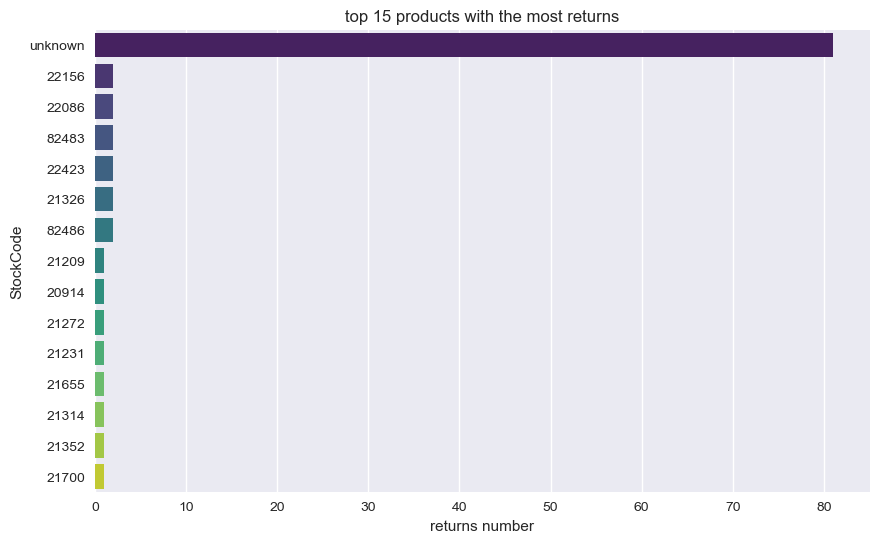

In [64]:
plt.figure(figsize=(10,6))
top_15= returns.groupby('StockCode')['InvoiceNo'].count().sort_values(ascending=False).head(15)
sns.barplot(x=top_15.values, y=top_15.index, palette='viridis')
plt.title('top 15 products with the most returns')
plt.xlabel('returns number')
plt.tight_layout
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_20612\3291742899.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_returns.index, y=monthly_returns.values, palette='coolwarm')


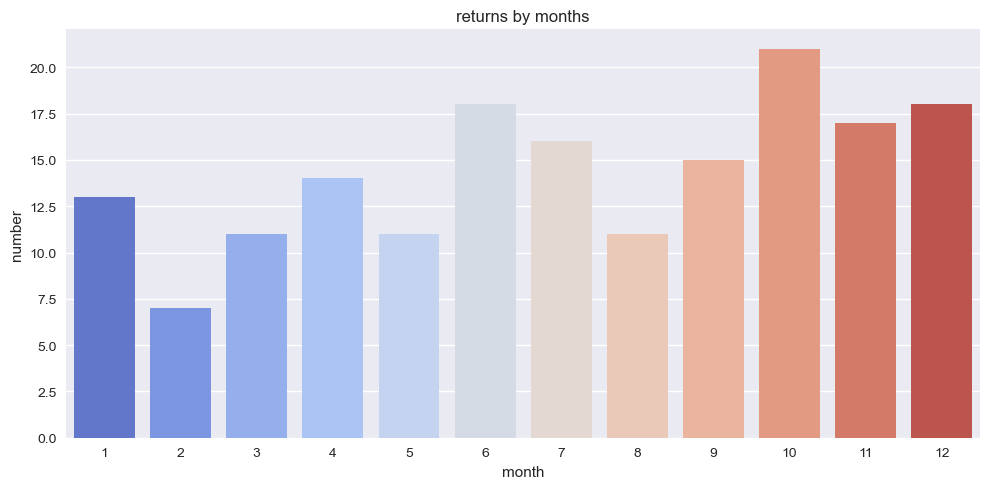

In [65]:
plt.figure(figsize=(10,5))
monthly_returns= returns.groupby('Month')['InvoiceNo'].count()
sns.barplot(x=monthly_returns.index, y=monthly_returns.values, palette='coolwarm')
plt.title('returns by months')
plt.xlabel('month')
plt.ylabel('number')
plt.tight_layout()
plt.show()

### <font color="4FB7B3">- 3)relation between priceunit and quantity</font>

In [66]:
correlation= df['UnitPrice'].corr(df['Quantity'])
print(f'correlation unitprice/quantity: {correlation: .3f}')

correlation unitprice/quantity: -0.309


#### scatter plot

In [67]:
df['PriceCategory']= pd.cut(df['UnitPrice'], bins=[0,1,5,20], labels=['low', 'medium', 'high'])
price_grouped= df.groupby('PriceCategory')['Quantity'].agg(['mean','sum','count'])
print('\n price category statistics:')
print(price_grouped)


 price category statistics:
                   mean        sum   count
PriceCategory                             
low            9.128733   887605.0   97232
medium         5.119707  1669813.0  326154
high           2.850492   119028.0   41757


C:\Users\User\AppData\Local\Temp\ipykernel_20612\3291253784.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['PriceCategory']= pd.cut(df['UnitPrice'], bins=[0,1,5,20], labels=['low', 'medium', 'high'])
C:\Users\User\AppData\Local\Temp\ipykernel_20612\3291253784.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_grouped= df.groupby('PriceCategory')['Quantity'].agg(['mean','sum','count'])


#### box plot

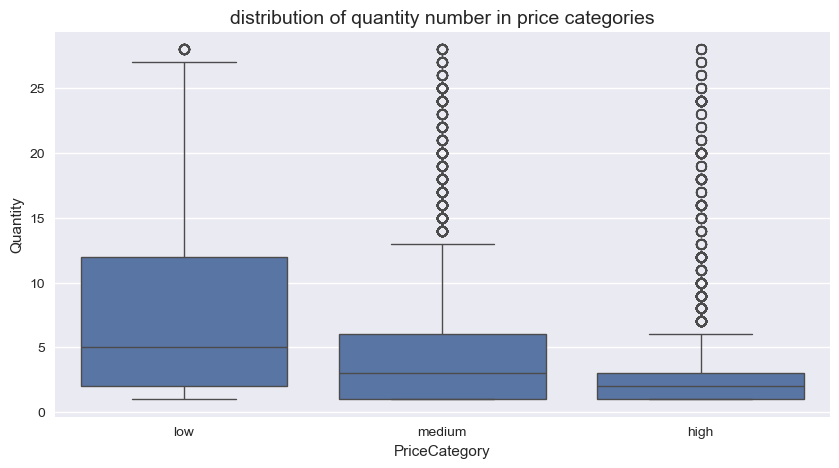

In [68]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='PriceCategory', y='Quantity')
plt.title('distribution of quantity number in price categories', fontsize=14)
plt.show()

# <font color="696FC7">Predictive Analysis</font>

### <font color="58A0C8">- 1)Predict next month's sales </font>

In [69]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled,Year,Month,Day,Hour,DayOfWeek,TotalAmount,unitPrice,PriceCategory
0,555200,unknown,HANGING JAM JAR T-LIGHT HOLDER,24.0,2011-06-01 12:05:00,0.85,17315,United Kingdom,False,2011,6,1,12,2,20.40,0.85,low
1,554974,unknown,GOLD FISHING GNOME,4.0,2011-05-27 17:14:00,6.95,14031,United Kingdom,False,2011,5,27,17,4,27.80,6.95,high
2,550972,unknown,SET/6 RED SPOTTY PAPER CUPS,4.0,2011-04-21 17:05:00,0.65,14031,United Kingdom,False,2011,4,21,17,3,2.60,0.65,low
3,576652,unknown,PACK 3 BOXES CHRISTMAS PANETTONE,3.0,2011-11-16 10:39:00,1.95,17198,United Kingdom,False,2011,11,16,10,2,5.85,1.95,medium
4,546157,unknown,RETROSPOT LAMP,2.0,2011-03-10 08:40:00,2.08,13502,United Kingdom,False,2011,3,10,8,3,19.90,9.95,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22367,CHILDRENS APRON SPACEBOY DESIGN,8.0,2011-12-09 12:50:00,1.95,12680,France,False,2011,12,9,12,4,15.60,1.95,medium
541905,581587,22629,SPACEBOY LUNCH BOX,12.0,2011-12-09 12:50:00,1.95,12680,France,False,2011,12,9,12,4,23.40,1.95,medium
541906,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12.0,2011-12-09 12:50:00,0.85,12680,France,False,2011,12,9,12,4,10.20,0.85,low
541907,581587,22899,CHILDREN'S APRON DOLLY GIRL,6.0,2011-12-09 12:50:00,2.10,12680,France,False,2011,12,9,12,4,12.60,2.10,medium


In [70]:
df['InvoiceDate']= pd.to_datetime(df['InvoiceDate'])
daily_sales= df.assign(Date=df['InvoiceDate'].dt.date).groupby('Date').agg({
    'TotalAmount': 'sum',
    'CustomerID': 'nunique',
    'Country': 'nunique'
}).reset_index()
daily_sales.columns= ['Date','daily_sales','unique_customers','unique_countries']
daily_sales= daily_sales.copy()

C:\Users\User\AppData\Local\Temp\ipykernel_20612\763587959.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['InvoiceDate']= pd.to_datetime(df['InvoiceDate'])


In [71]:
daily_sales['Month']=df['InvoiceDate'].dt.month
daily_sales['Year']= df['InvoiceDate'].dt.year
daily_sales['Day']= df['InvoiceDate'].dt.day
daily_sales['DayOfWeek']= df['InvoiceDate'].dt.dayofweek
daily_sales['StockCode']= df['StockCode']
daily_sales

,Date,daily_sales,unique_customers,unique_countries,Month,Year,Day,DayOfWeek,StockCode
0,2010-12-01,198901.125726,95,7,6.0,2011.0,1.0,2.0,unknown
1,2010-12-02,135398.782334,100,3,5.0,2011.0,27.0,4.0,unknown
2,2010-12-03,159695.364581,50,10,4.0,2011.0,21.0,3.0,unknown
3,2010-12-05,107071.187198,76,5,11.0,2011.0,16.0,2.0,unknown
4,2010-12-06,140570.514995,81,4,3.0,2011.0,10.0,3.0,unknown
...,...,...,...,...,...,...,...,...,...
300,2011-12-05,306917.188704,106,10,6.0,2011.0,27.0,0.0,unknown
301,2011-12-06,175988.259259,106,7,5.0,2011.0,3.0,1.0,unknown
302,2011-12-07,196572.365726,96,8,12.0,2010.0,2.0,3.0,unknown
303,2011-12-08,163768.365453,106,5,12.0,2010.0,17.0,4.0,unknown


In [72]:
daily_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305 entries, 0 to 304
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              305 non-null    object 
 1   daily_sales       305 non-null    float64
 2   unique_customers  305 non-null    int64  
 3   unique_countries  305 non-null    int64  
 4   Month             264 non-null    float64
 5   Year              264 non-null    float64
 6   Day               264 non-null    float64
 7   DayOfWeek         264 non-null    float64
 8   StockCode         264 non-null    object 
dtypes: float64(5), int64(2), object(2)
memory usage: 21.6+ KB


In [73]:
X= daily_sales[['unique_countries','Month','Year','Day','unique_customers','DayOfWeek']]
y= daily_sales['daily_sales']


In [74]:
daily_sales=daily_sales.dropna()

In [75]:
model= LinearRegression()
model.fit(X,y)

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
daily_sales

In [ ]:
# X= daily_sales[['unique_countries','Month','Year','Day','unique_customers','DayOfWeek']]
next_year= model.predict([[7,6,2012,1.0,95,2]])
print(f'predicted sales for next June: {next_day[0]:.2f} pounds')

### <font color="58A0C8">- 2)Return probability of a certain customer</font>

In [ ]:
df

In [ ]:
def calculate_return_probability(customer_id):
    customer_orders= df[df['CustomerID']== customer_id]
    if customer_orders.empty:
        return 'not found'
    else:
         total_orders= len(customer_orders)
         cancelled_orders= customer_orders['IsCancelled'].sum()
         probability= cancelled_orders / total_orders

         return {
             'CustomerID' : customer_id,
             'Total Orders' : total_orders,
             'Cancelled Orders' : cancelled_orders,
             'return Probability' : probability
    }

result= calculate_return_probability(14606)
print(result)

# <font color="696FC7">Prescriptive Analysis</font>

### <font color="58A0C8">- 1)Profitable products for sale</font>

In [78]:
df_without_c= df[~df['InvoiceNo'].str.contains('C' ,na=False)]
df_without_c

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled,Year,Month,Day,Hour,DayOfWeek,TotalAmount,unitPrice,PriceCategory
0,555200,unknown,HANGING JAM JAR T-LIGHT HOLDER,24.0,2011-06-01 12:05:00,0.85,17315,United Kingdom,False,2011,6,1,12,2,20.40,0.85,low
1,554974,unknown,GOLD FISHING GNOME,4.0,2011-05-27 17:14:00,6.95,14031,United Kingdom,False,2011,5,27,17,4,27.80,6.95,high
2,550972,unknown,SET/6 RED SPOTTY PAPER CUPS,4.0,2011-04-21 17:05:00,0.65,14031,United Kingdom,False,2011,4,21,17,3,2.60,0.65,low
3,576652,unknown,PACK 3 BOXES CHRISTMAS PANETTONE,3.0,2011-11-16 10:39:00,1.95,17198,United Kingdom,False,2011,11,16,10,2,5.85,1.95,medium
4,546157,unknown,RETROSPOT LAMP,2.0,2011-03-10 08:40:00,2.08,13502,United Kingdom,False,2011,3,10,8,3,19.90,9.95,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22367,CHILDRENS APRON SPACEBOY DESIGN,8.0,2011-12-09 12:50:00,1.95,12680,France,False,2011,12,9,12,4,15.60,1.95,medium
541905,581587,22629,SPACEBOY LUNCH BOX,12.0,2011-12-09 12:50:00,1.95,12680,France,False,2011,12,9,12,4,23.40,1.95,medium
541906,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12.0,2011-12-09 12:50:00,0.85,12680,France,False,2011,12,9,12,4,10.20,0.85,low
541907,581587,22899,CHILDREN'S APRON DOLLY GIRL,6.0,2011-12-09 12:50:00,2.10,12680,France,False,2011,12,9,12,4,12.60,2.10,medium


In [80]:
product_analysis= df_without_c.groupby('Description').agg({
'Quantity': 'sum',
'TotalAmount': 'sum'
}).reset_index()
product_analysis

,Description,Quantity,TotalAmount
0,*USB OFFICE MIRROR BALL,2.0,16.940000
1,10 COLOUR SPACEBOY PEN,3648.0,30934.703806
2,12 COLOURED PARTY BALLOONS,1609.0,33545.958255
3,12 DAISY PEGS IN WOOD BOX,310.0,536.520000
4,12 EGG HOUSE PAINTED WOOD,138.0,3219.992890
...,...,...,...
3997,ZINC T-LIGHT HOLDER STARS SMALL,2556.0,36619.984035
3998,ZINC TOP 2 DOOR WOODEN SHELF,12.0,236.080000
3999,ZINC WILLIE WINKIE CANDLE STICK,1930.0,40020.495595
4000,ZINC WIRE KITCHEN ORGANISER,30.0,239.970000


In [81]:
#priority score
product_analysis['sales_pct']= product_analysis['Quantity']/product_analysis['Quantity'].max()
product_analysis['revenue_pct']= product_analysis['TotalAmount']/product_analysis['TotalAmount'].max()
product_analysis['priority']= (product_analysis['sales_pct']*0.4)+(product_analysis['revenue_pct'] * 0.6)

In [82]:
#top products
top_products= product_analysis.nlargest(15,'priority')[['Description','Quantity','TotalAmount','priority']]

In [86]:
print('recommended products to stock for increased profit:')
print(top_products.to_string(index=False))

recommended products to stock for increased profit:
                       Description  Quantity   TotalAmount  priority
           JUMBO BAG RED RETROSPOT   13288.0 235010.791321  0.954252
WHITE HANGING HEART T-LIGHT HOLDER   11728.0 168337.291691  0.742441
     ASSORTED COLOUR BIRD ORNAMENT   13369.0 132839.902334  0.695562
   PACK OF 72 RETROSPOT CAKE CASES   15004.0 108345.067656  0.676613
          REGENCY CAKESTAND 3 TIER    7875.0 160545.073392  0.619828
             HEART OF WICKER SMALL    7432.0 143148.493022  0.563603
           LUNCH BAG  BLACK SKULL.    7266.0 133378.581233  0.534234
      SET OF 4 PANTRY JELLY MOULDS    6840.0 135103.791462  0.527281
            JUMBO STORAGE BAG SUKI    6426.0 136457.224123  0.519700
                VINTAGE SNAP CARDS    6788.0 129440.422793  0.511436
            JAM MAKING SET PRINTED    8857.0  95569.015639  0.480118
           JUMBO BAG PINK POLKADOT    6978.0 107818.917427  0.461300
                     PARTY BUNTING    8061.0  95649

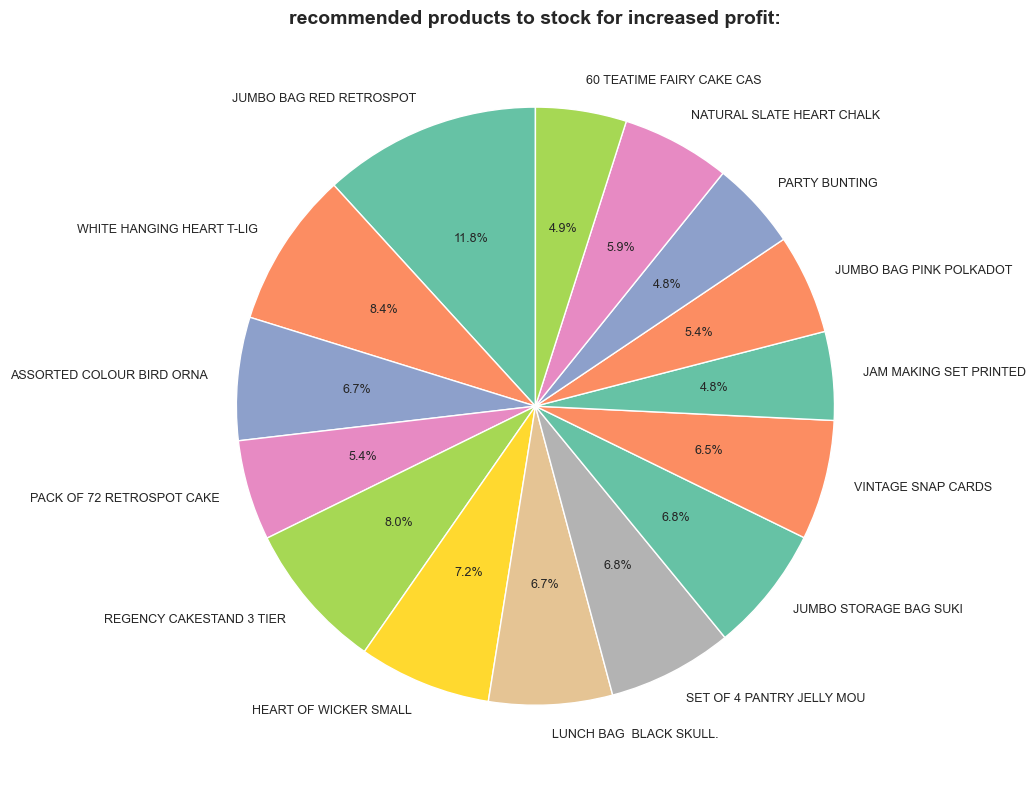

In [94]:
plt.figure(figsize=(10,8))
data= top_products['TotalAmount'].values
labels= top_products['Description'].str[:25].values
wedges,texts,autotexts= plt.pie(x=data,
                            labels=labels,
                            autopct='%1.1f%%',
                            startangle=90,
                            colors=sns.color_palette('Set2',10),
                            textprops={'fontsize':9},
                            wedgeprops= {'edgecolor':'white','linewidth':1}
)
plt.title('recommended products to stock for increased profit:',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()

### <font color="58A0C8">- 2)Recommended discount packages for loyal customers</font>

In [107]:
rmf= df_without_c.groupby('CustomerID').agg(
   recency=('InvoiceDate',lambda x: (df_without_c['InvoiceDate'].max() - x.max()).days),
   frequency=('InvoiceNo','count'),
    monetary=('TotalAmount','sum')
).reset_index()

mean_freq= rmf['frequency'].mean()
mean_mon= rmf['monetary'].mean()
#loyalty level and discount packege
def get_strategy(row):
    if row['monetary']>mean_mon:
        if row['frequency']>mean_freq:
            return 'VIP Gold: Exclusive discounts + priority service'
        else:
            return 'Volume-based: Tiered discount on bulk purchases'
    else:
        return 'Win-back: Attractive coupon for return purchase'

rmf['strategy']= rmf.apply(get_strategy, axis=1)
# recommendations for top customers
print(rmf.sort_values('monetary',ascending=False).head(10))
      

     CustomerID  recency  frequency      monetary  \
4328    unknown        0     116395  4.187572e+06   
1876      14911        0       4933  5.189983e+05   
561       13089        2       1604  3.176944e+05   
4003      17841        1       6831  2.301246e+05   
1288      14096        3       4511  1.784493e+05   
1687      14646        1       1818  1.664693e+05   
1433      14298        7       1437  1.655372e+05   
557       13081       11        903  1.645739e+05   
3888      17675        0        637  1.224177e+05   
2173      15311        0       2096  1.109089e+05   

                                              strategy  
4328  VIP Gold: Exclusive discounts + priority service  
1876  VIP Gold: Exclusive discounts + priority service  
561   VIP Gold: Exclusive discounts + priority service  
4003  VIP Gold: Exclusive discounts + priority service  
1288  VIP Gold: Exclusive discounts + priority service  
1687  VIP Gold: Exclusive discounts + priority service  
1433  VIP Gold: E